In [34]:
import numpy as np
import math as m
from graphviz import Digraph

In [35]:
class Value :
    def __init__( self , data, _children=(), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda : None

    def __repr__(self):
        return f'Value(data = {self.data})'
    
    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')
        def _backward() :
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad 
        out._backward = _backward  
        return out
     
    def __mul__(self, other):
        other = other if isinstance (other,Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')
        def _backward() :
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward    
        return out
    
    def tanh(self) :
        x = self.data
        t = (m.exp(2*x) - 1)/(m.exp(2*x) + 1)
        out = Value(t , (self, ), 'tanh')
        def _backward() :
            self.grad += (1 - t**2)*out.grad
        out._backward = _backward
        return out
    
    def backword(self) :
        topo = []
        visited = set()
        def build_topo(item) :
            if item not in visited :
                visited.add(item)
                for child in item._prev :
                    build_topo(child)
                topo.append(item)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo) :
            node._backward()
        

In [36]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [37]:
#inputs x1, x2 :
x1 = Value(5.0, label='x1')
x2 = Value(10.0, label='x2')
#weights w1, w2 :
w1 = Value(-1.0, label='w1')
w2 = Value(2.0, label= 'w2')
b = Value(-12.0, label='b')
x1w1 = x1 * w1 ; x1w1.label = 'x1 * w1'
x2w2 = x2 * w2 ; x2w2.label = 'x2 * w2'
x1xw1x2w2 = x1w1 + x2w2 ; x1xw1x2w2.label = 'x1w1 + x2w2'
n = x1xw1x2w2 + b ; n.label = 'n'
out = n.tanh() ; out.label = 'out'



In [38]:
out.backword()

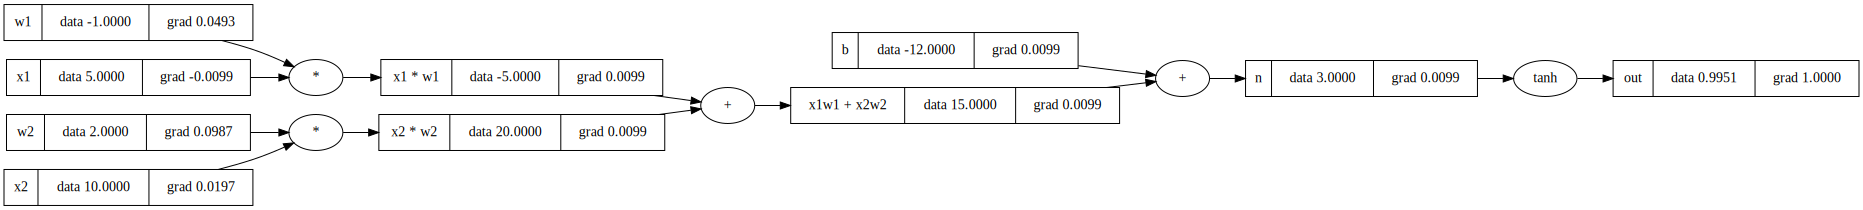

In [39]:
draw_dot(out)